# Prédiction de l’Approbation de Crédit - Loan Dataset (US & Canada)

**Dataset :** `Loan_approval_data.csv` &nbsp;|&nbsp; **Observations :** 50 000 &nbsp;|&nbsp; **Variable cible :** `loan_status`

---




![image](img.png)

## Contexte et Objectif

Ce projet vise à analyser et modéliser le risque de crédit à partir d’un dataset réaliste intégrant des caractéristiques financières et socio-économiques des emprunteurs.

#### Les variables disponibles incluent notamment :
- **Données démographiques :** âge, statut professionnel
- **Situation financière :** revenus annuels, dette actuelle, épargne
- **Historique de crédit :** score, incidents, retards
- **Caractéristiques du prêt :** montant, taux d’intérêt, objectif

#### Objectifs :
- Comprendre les facteurs influençant le défaut de paiement
- Construire un modèle prédictif fiable
- Aider à la décision d’octroi de crédit

---

## Problématique Centrale : Le désequilibre des Classes

L’analyse de la variable cible montre un **déséquilibre significatif** :
- 80 % de prêts approuvés (loan_status = 1)
- 20 % de prêts refusés (loan_status = 0)


---
## Plan du Notebook

| Etape | Description |  
|-------|-------------|
| **0** |  Importation des librairies et chargement des données | 
| **1** | Analyse Exploratoire (EDA) | 
| **2** | Preprocessing : split, log transformations , Encoding , SMOTE | 2.1 – 2.4 |
| **3** | Sélection des variables (Khi-2 , ANOVA) | 4.1 – 4.2 |
| **4** | Modélisation des 3 modèles | 5.1 – 5.4 |
| **5** | Résultats des modèles (métriques, courbes ROC) | 6.1 – 6.5 |
| **6** | Comparaison des modeles | 7.1 – 7.4 |
| **7** | Conclusion et synthèse finale | 9.1 – 9.2 |

---

## Modèles Utilisés

| **Regression Logistique**
| **Arbre de Decision** 
| **Random Forest** 

---


## Installation et importation des packages

In [34]:
# Install and import required packages

# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Data preprocessing
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils import resample
from sklearn.model_selection import cross_val_score

# Feature selection
from sklearn.feature_selection import RFECV
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Metrics and evaluation
from sklearn.metrics import (roc_auc_score, classification_report, 
                           confusion_matrix, roc_curve, auc, 
                           precision_recall_curve, f1_score)

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Importation de la dataset

In [35]:
import pandas as pd

df = pd.read_csv(r"C:\Users\yolde\OneDrive\Bureau\Loan\data\Loan_approval_data.csv")
df.head()

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST129262,45,Self-Employed,21.9,40061,660,9.6,345,4168,0,0,0,Personal Loan,Home Improvement,45900,11.55,0.104,1.146,0.382,1
1,CUST121151,51,Employed,15.1,62071,662,26.7,2808,7937,0,0,0,Line of Credit,Personal,30100,10.27,0.128,0.485,0.162,1
2,CUST106607,37,Employed,13.8,15235,631,11.8,214,4615,0,0,0,Personal Loan,Personal,28300,14.03,0.303,1.858,0.619,1
3,CUST143202,53,Self-Employed,2.8,30466,807,23.8,7683,1014,0,0,0,Credit Card,Education,32700,15.96,0.033,1.073,0.358,1
4,CUST130173,40,Employed,9.4,60576,615,20.7,4695,9733,0,2,0,Line of Credit,Personal,36200,11.36,0.161,0.598,0.199,1


## ETAPE 1 — Analyse Exploratoire (EDA)

### 1-1 Inspection initiale des données

In [3]:
df.shape

(50000, 20)

In [4]:
df.columns

Index(['customer_id', 'age', 'occupation_status', 'years_employed',
       'annual_income', 'credit_score', 'credit_history_years',
       'savings_assets', 'current_debt', 'defaults_on_file',
       'delinquencies_last_2yrs', 'derogatory_marks', 'product_type',
       'loan_intent', 'loan_amount', 'interest_rate', 'debt_to_income_ratio',
       'loan_to_income_ratio', 'payment_to_income_ratio', 'loan_status'],
      dtype='object')

### 1-2 Statistique descriptive

In [5]:
df.describe()

,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,37.377600,8.594870,53330.570900,665.815140,9.544996,4507.478840,13395.706520,0.012800,0.375420,0.082220,32383.122000,14.951161,0.250877,0.639173,0.213051,0.890000
std,11.016651,8.002109,34750.598666,58.785653,7.447377,15009.954685,12160.555554,0.112412,0.651743,0.298633,26414.070625,4.070832,0.132104,0.445497,0.148505,0.312893
min,18.000000,0.000000,15000.000000,348.000000,0.000000,0.000000,64.000000,0.000000,0.000000,0.000000,500.000000,6.020000,0.002000,0.008000,0.003000,0.000000
25%,30.000000,1.900000,28968.750000,627.000000,3.100000,190.750000,5353.000000,0.000000,0.000000,0.000000,11200.000000,11.410000,0.149000,0.287000,0.096000,1.000000
50%,37.000000,6.300000,44325.000000,665.000000,8.000000,808.000000,9838.000000,0.000000,0.000000,0.000000,25100.000000,14.960000,0.238000,0.555000,0.185000,1.000000
75%,45.000000,13.200000,67507.000000,705.000000,14.500000,3000.000000,17393.000000,0.000000,1.000000,0.000000,47900.000000,18.340000,0.339000,0.909000,0.303000,1.000000
max,70.000000,39.900000,250000.000000,850.000000,30.000000,300000.000000,163344.000000,1.000000,7.000000,4.000000,100000.000000,23.000000,0.800000,2.001000,0.667000,1.000000


**Statistiques descriptives :**
Ce tableau fournit un résumé statistique des variables numériques, incluant les mesures de tendance centrale (moyenne, médiane), de dispersion (écart-type) et d’étendue (minimum, maximum). Il permet de mieux comprendre la distribution de chaque variable quantitative.

### 1-3 Types des données et valeurs manquantes

In [36]:
# =========================
# 1. Dictionnaire des descriptions
# =========================

variable_description = {
    'age': 'Âge du client',
    'occupation_status': 'Statut professionnel (ex: Student, Self-Employed)',
    'annual_income': 'Revenu annuel du client',
    'savings_assets': 'Épargne ou actifs financiers',
    'current_debt': 'Dette actuelle du client',
    'credit_score': 'Score de crédit (fiabilité financière)',
    'credit_history_years': 'Durée de l’historique de crédit',
    'defaults_on_file': 'Nombre de défauts passés',
    'delinquencies_last_2yrs': 'Retards de paiement récents',
    'derogatory_marks': 'Incidents financiers négatifs',
    'loan_amount': 'Montant du prêt demandé',
    'interest_rate': 'Taux d’intérêt du prêt',
    'loan_intent': 'Objectif du prêt (education, medical, etc.)',
    'product_type': 'Type de produit (Personal Loan, Line of Credit)',
    'debt_to_income_ratio': 'Ratio dette / revenu',
    'loan_to_income_ratio': 'Ratio prêt / revenu',
    'loan_status': 'Variable cible (0 = refusé, 1 = accepté)'
}

# =========================
# 2. Création du tableau
# =========================

summary_table = pd.DataFrame({
    'Variable': df.columns,
    'Type': df.dtypes.values,
    'Missing Values': df.isnull().sum().values,
    'Unique Values': df.nunique().values
})

# =========================
# 3. Ajouter description
# =========================

summary_table['Description'] = summary_table['Variable'].map(variable_description)

# =========================
# 4. Affichage final
# =========================

summary_table

,Variable,Type,Missing Values,Unique Values,Description
0,customer_id,object,0,27526,NaN
1,age,int64,0,53,Âge du client
2,occupation_status,object,0,3,"Statut professionnel (ex: Student, Self-Employed)"
3,years_employed,float64,0,394,NaN
4,annual_income,int64,0,22517,Revenu annuel du client
5,credit_score,int64,0,409,Score de crédit (fiabilité financière)
6,credit_history_years,float64,0,301,Durée de l’historique de crédit
7,savings_assets,int64,0,8080,Épargne ou actifs financiers
8,current_debt,int64,0,17673,Dette actuelle du client
9,defaults_on_file,int64,0,2,Nombre de défauts passés


### 1-4 Suppression des doublons et de la colonne "customer_id"

In [37]:
df = df.drop(columns=["customer_id"])
df = df.drop_duplicates()

### 1-5 Analyse et distribution de la variable cible 


Distribution de la variable cible (loan_status):


,Count,Percentage
loan_status,,
1,22026,80.018891
0,5500,19.981109


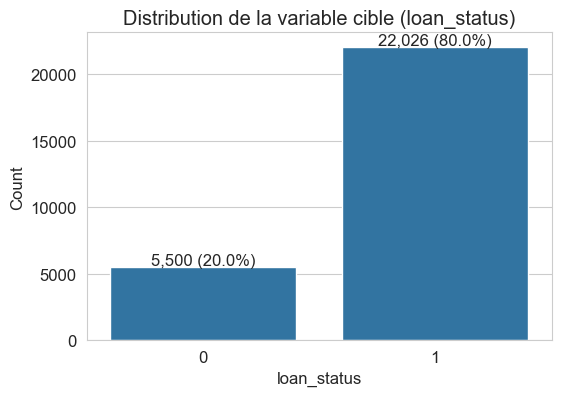

In [38]:
# Calculate loan_status statistics

default_counts = df['loan_status'].value_counts()
default_percent = df['loan_status'].value_counts(normalize=True) * 100
default_stats = pd.DataFrame({
    'Count': default_counts,
    'Percentage': default_percent
})
print("\nDistribution de la variable cible (loan_status):")
display(default_stats)

# Visualize distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='loan_status')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f} ({p.get_height()/len(df)*100:.1f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')
plt.title('Distribution de la variable cible (loan_status)')
plt.ylabel('Count')
plt.show()

### Distribution de la variable cible :


#### Déséquilibre des classes :
 La variable cible **loan_statuts** présente un déséquilibre entre les classes. 

Environ 80 % des prêts n’ont pas fait défaut (classe 0), tandis que 20 % correspondent à des défauts de paiement (classe 1).

Ce déséquilibre doit être pris en compte lors de l’entraînement et de l’évaluation des modèles, car il peut biaiser les performances (le modèle risque de favoriser la classe majoritaire).

 Des techniques comme  l’utilisation de métriques adaptées (ex : F1-score, AUC) peuvent être nécessaires.

## 1-6 Analyse univariée

#### Étude des distributions des variables individuelles

In [39]:
# Numerical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('loan_status')  # Remove target variable

# Categorical features
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

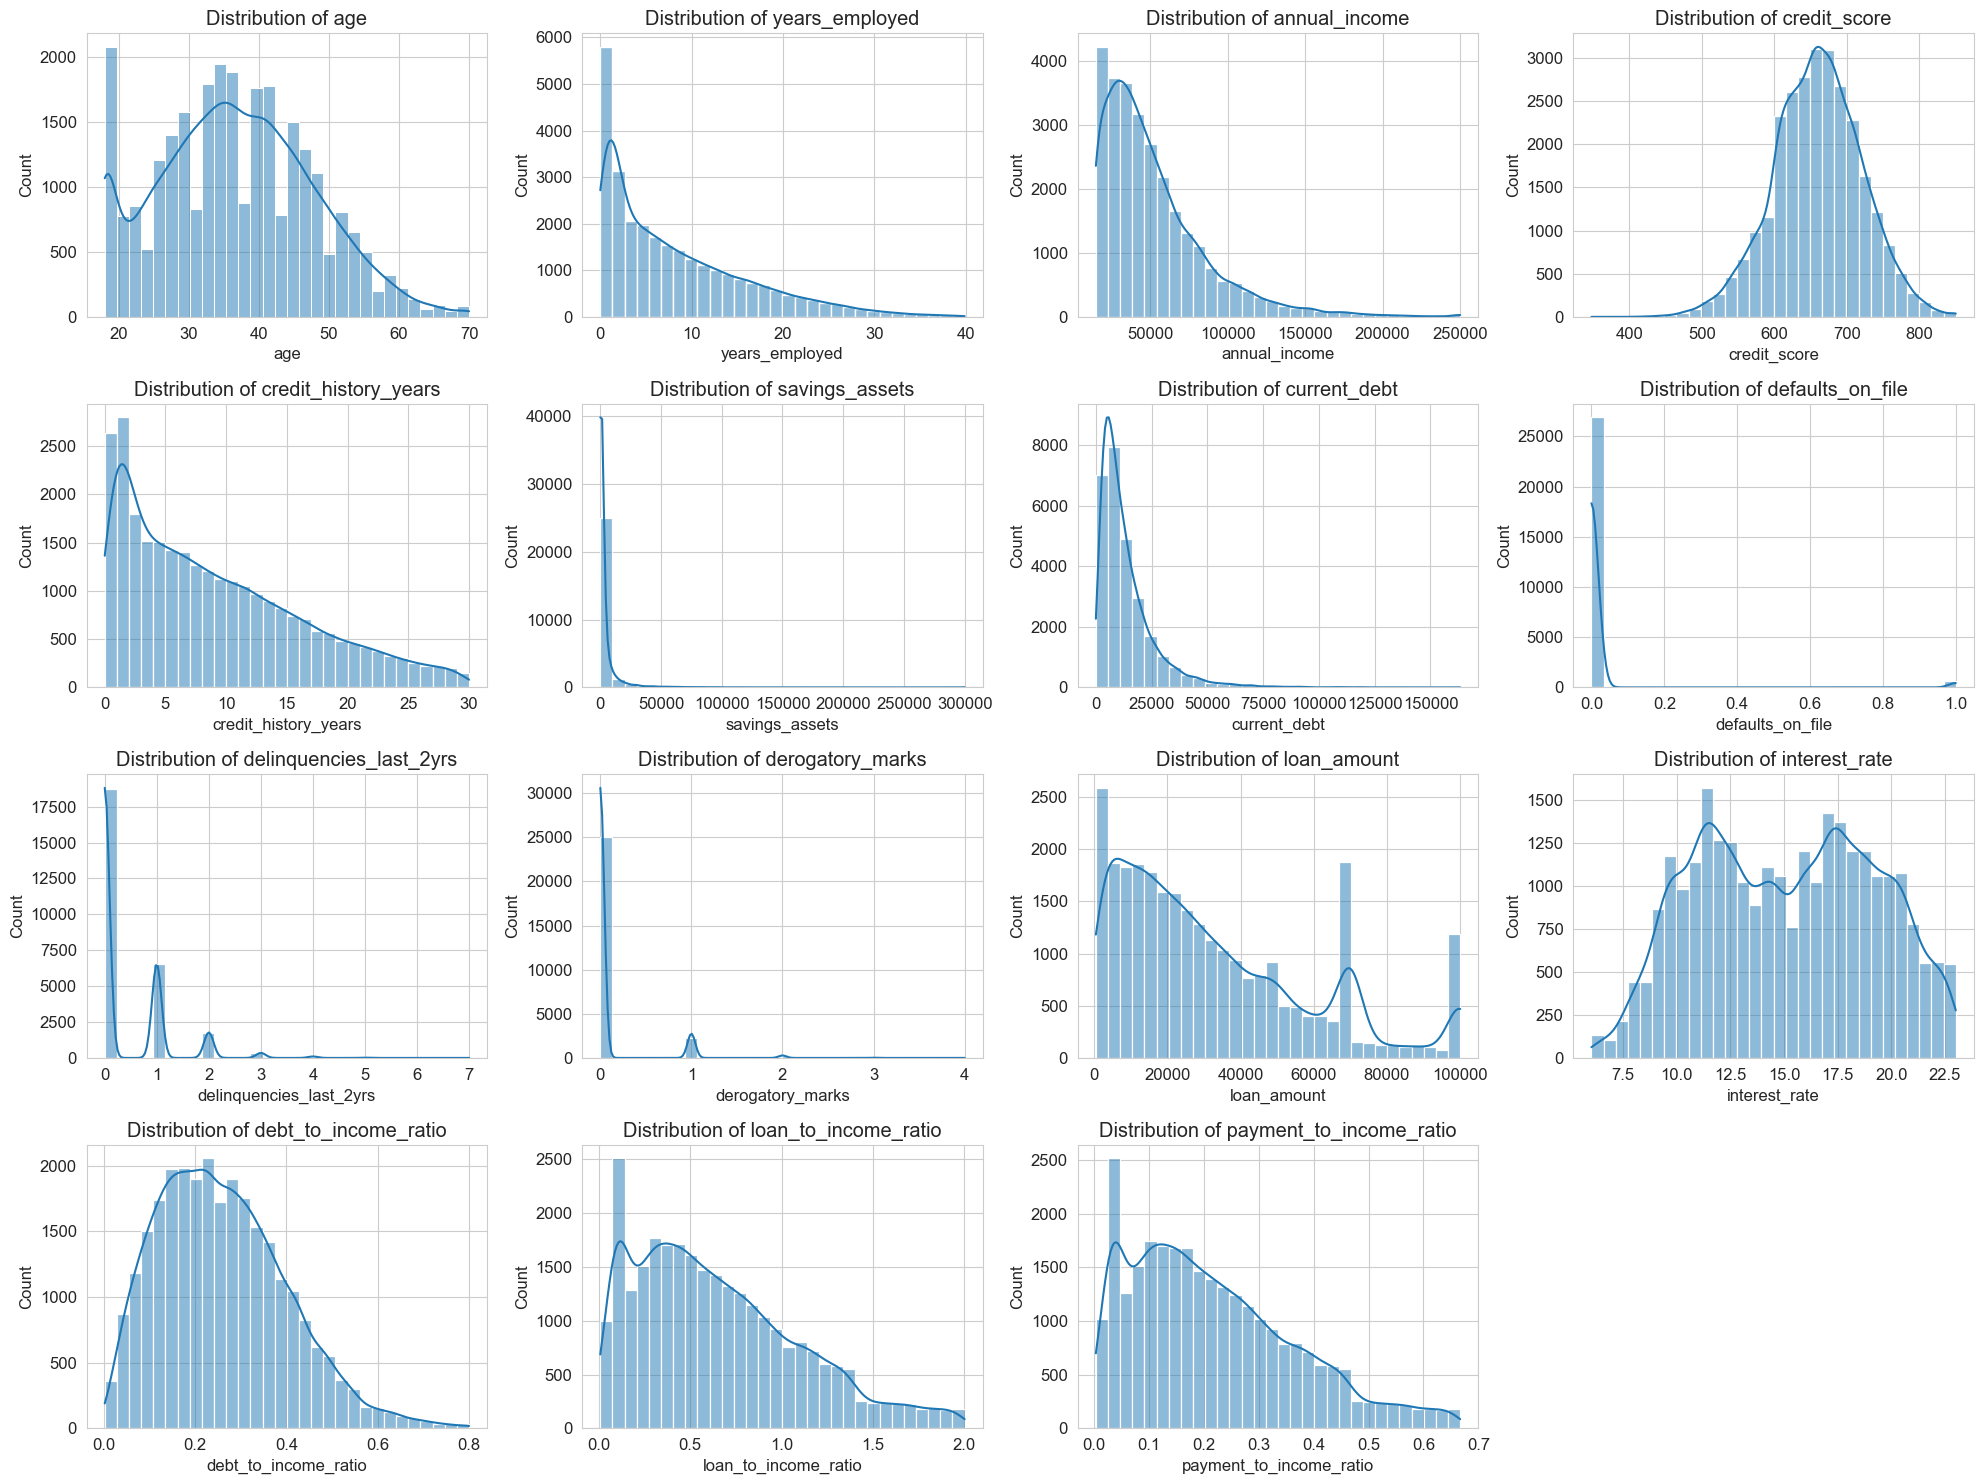

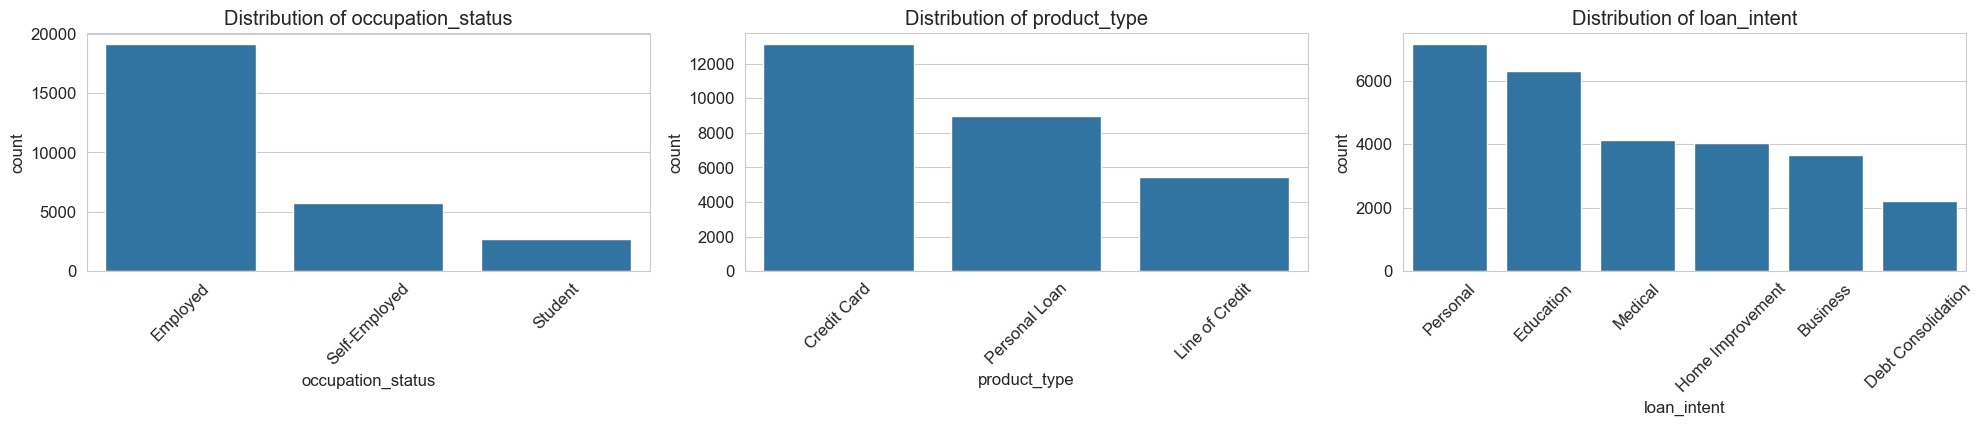

In [40]:
# Plot distributions for numerical features
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

# Plot distributions for categorical features
plt.figure(figsize=(20, 15))
for i, col in enumerate(cat_cols):
    plt.subplot(4, 3, i+1)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.show()

###  Analyse de la distribution des variables numériques :

- **age:** Distribution quasi normale, majorité entre 25–45 ans.
- **years_employed:** Asymétrique à droite, beaucoup de faibles expériences.
- **annual_income:** Très asymétrique à droite, présence de valeurs extrêmes (log recommandé).
- **credit_score:** Distribution normale, bien équilibrée.
- **credit_history_years:** Asymétrique à droite, historique souvent court.
- **savings_assets:** Très asymétrique, forte concentration sur faibles valeurs (log recommandé).
- **current_debt:** Asymétrique à droite, quelques dettes élevées.
- **defaults_on_file:** Majorité de zéros, variable très discriminante.
- **delinquencies_last_2yrs:** Très asymétrique, peu de retards.
- **derogatory_marks:** Concentrée sur 0, incidents rares.
- **loan_amount:** Asymétrique, majorité de petits/moyens prêts.
- **interest_rate:** Distribution assez uniforme.
- **debt_to_income_ratio:** Asymétrique, bon indicateur de risque.
- **loan_to_income_ratio:** Asymétrique, quelques valeurs élevées.
- **payment_to_income_ratio:** Asymétrique, pression financière variable.

### Variables Catégorielles:
 La variable **occupation_status** montre une forte dominance des individus employés, avec moins de travailleurs indépendants et très peu d’étudiants, indiquant un déséquilibre des catégories.

  Concernant **product_type,** les cartes de crédit et les prêts personnels sont les produits les plus fréquents, tandis que les lignes de crédit sont moins représentées.

 La variable **loan_intent** présente une répartition relativement variée, avec une dominance des prêts à usage personnel et éducation, tandis que la consolidation de dettes est moins fréquente.

### Calcul de skewness (degré d'asymétrie)

In [41]:
import pandas as pd

# sélectionner les variables numériques
num_cols = df.select_dtypes(include=['int64', 'float64'])

# calcul de la skewness
skewness = num_cols.skew()

print(skewness.sort_values(ascending=False))

savings_assets             10.992923
defaults_on_file            6.327523
derogatory_marks            3.671023
current_debt                2.439709
delinquencies_last_2yrs     2.023859
annual_income               1.783612
years_employed              1.158455
loan_amount                 0.941179
credit_history_years        0.780615
loan_to_income_ratio        0.762411
payment_to_income_ratio     0.762267
debt_to_income_ratio        0.616318
age                         0.235268
interest_rate              -0.002716
credit_score               -0.109295
loan_status                -1.501558
dtype: float64


## 1-7 Analyse bivariée

#### Étude des relations entre les variables explicatives et la variable cible

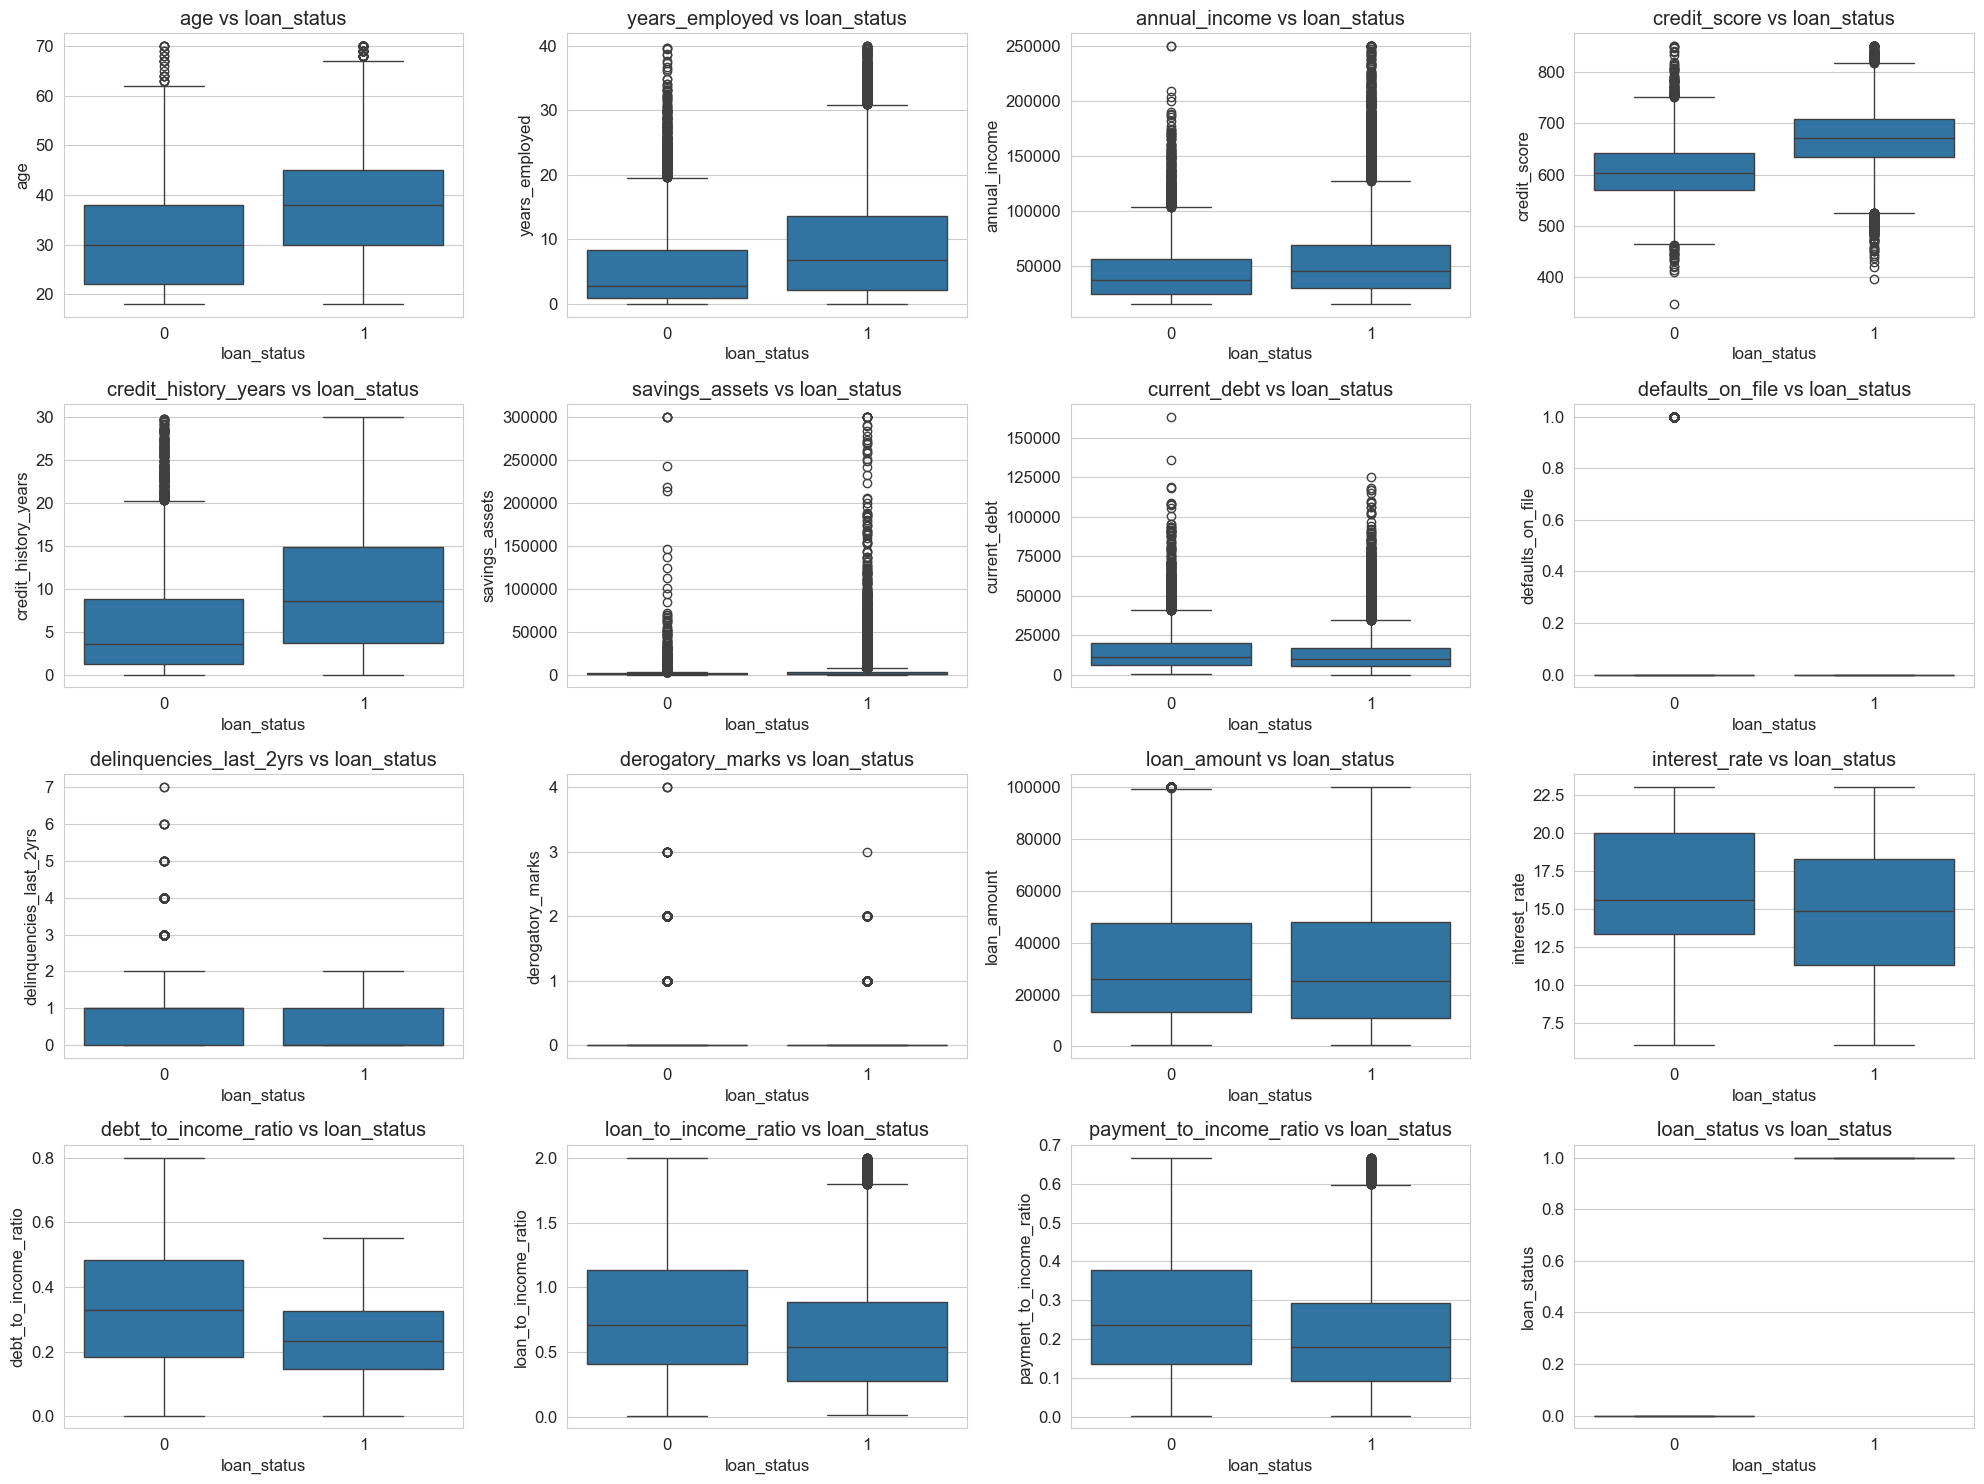

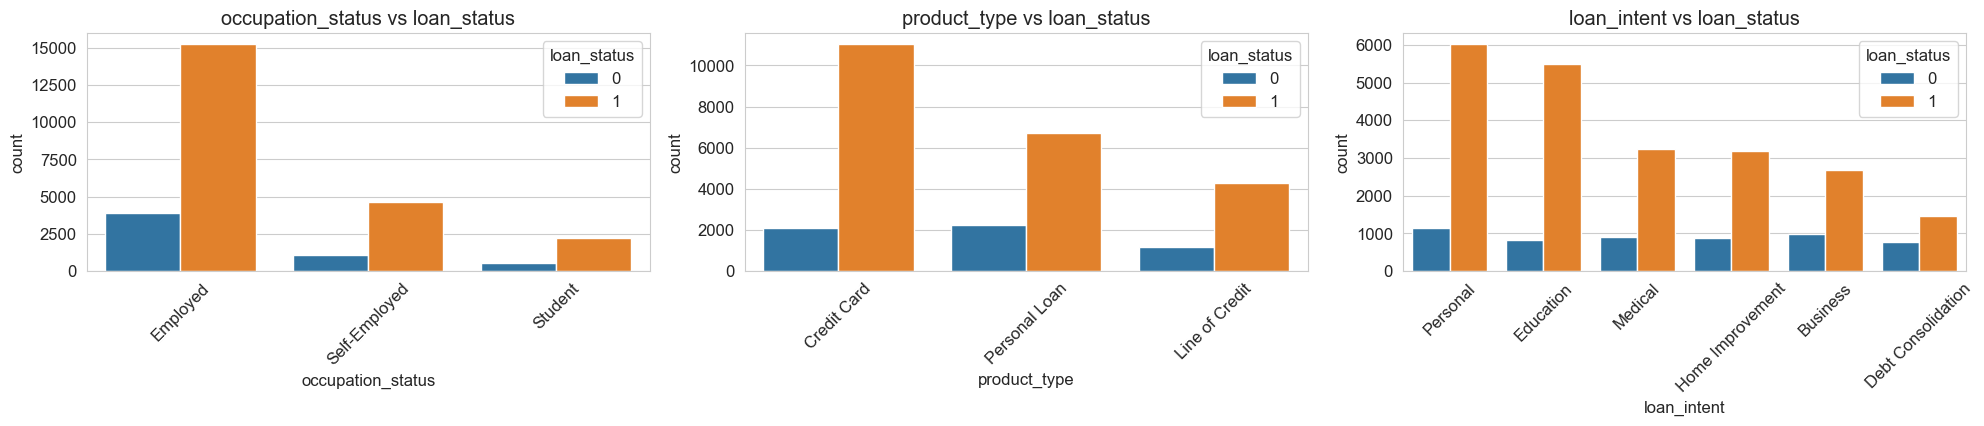

In [42]:
#Numerical features vs Default
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(data=df, x='loan_status', y=col)
    plt.title(f'{col} vs loan_status')
    plt.tight_layout()
plt.show()

# Categorical features vs Default
plt.figure(figsize=(20, 15))
for i, col in enumerate(cat_cols):
    plt.subplot(4, 3, i+1)
    sns.countplot(data=df, x=col, hue='loan_status', order=df[col].value_counts().index)
    plt.title(f'{col} vs loan_status')
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.show()

### Interprétation des Boxplots



#### 1. Age
- Plus élevé pour *loan_status = 1*

 Les emprunteurs plus âgés sont plus souvent approuvés  



#### 2. Years Employed
- Plus élevé pour *loan_status = 1*

Expérience professionnelle estun facteur clé d’approbation


#### 3. Annual Income
- Plus élevé pour *loan_status = 1*

 Revenu élevé → meilleure capacité de remboursement

---

#### 4. Credit Score
- Plus élevé pour *loan_status = 1*

→ indicateur principal de solvabilité

---

#### 5. Credit History Years
- Plus élevé pour *loan_status = 1*

Historique long = confiance  des prêteurs

---

#### 6. Savings / Assets
- Légèrement plus élevé pour *loan_status = 1*
- Forte dispersion

 Effet positif mais moins déterminant

---

#### 7. Current Debt
- Relativement similaire
- Légèrement plus faible pour *loan_status = 1*

 Moins de dette → meilleur profil

---

#### 8. Debt-to-Income Ratio
- Plus élevé pour *loan_status = 0*

 Ratio clé :
→ forte dette relative = refus

---

#### 9. Loan-to-Income Ratio
- Plus élevé pour *loan_status = 0*

 Montant de prêt trop élevé par rapport au revenu → refus

---

#### 10. Payment-to-Income Ratio
- Plus élevé pour *loan_status = 0*

 Charge mensuelle trop lourde → refus

---

#### 11. Loan Amount
- Similaire entre les deux groupes

 Peu discriminant seul

---

#### 12. Interest Rate
- Plus élevé pour*loan_status = 0**

 Profils risqués → taux plus élevés → souvent refusés

---

#### 13. Delinquencies (2 yrs)
- Légèrement plus élevé pour*loan_status = 0**

 Historique de retards = signal négatif

---

#### 14. Derogatory Marks
- Plus fréquent pour*loan_status = 0**

 Impact négatif sur l’approbation

---

#### 15. Defaults on File
- Présent surtout dans*loan_status = 0**

 Très mauvais signal → refus probable

---

### Conclusion globale

####  Profils approuvés (loan_status = 1)
- Revenus élevés
- Bon credit score
- Expérience stable
- Faibles ratios d’endettement

---

#### Profils refusés (loan_status = 0)
- Ratios financiers élevés
- Mauvais historique de crédit
- Charges importantes

---





## 1-8 Analyse des corrélations

#### Relations entre les variables

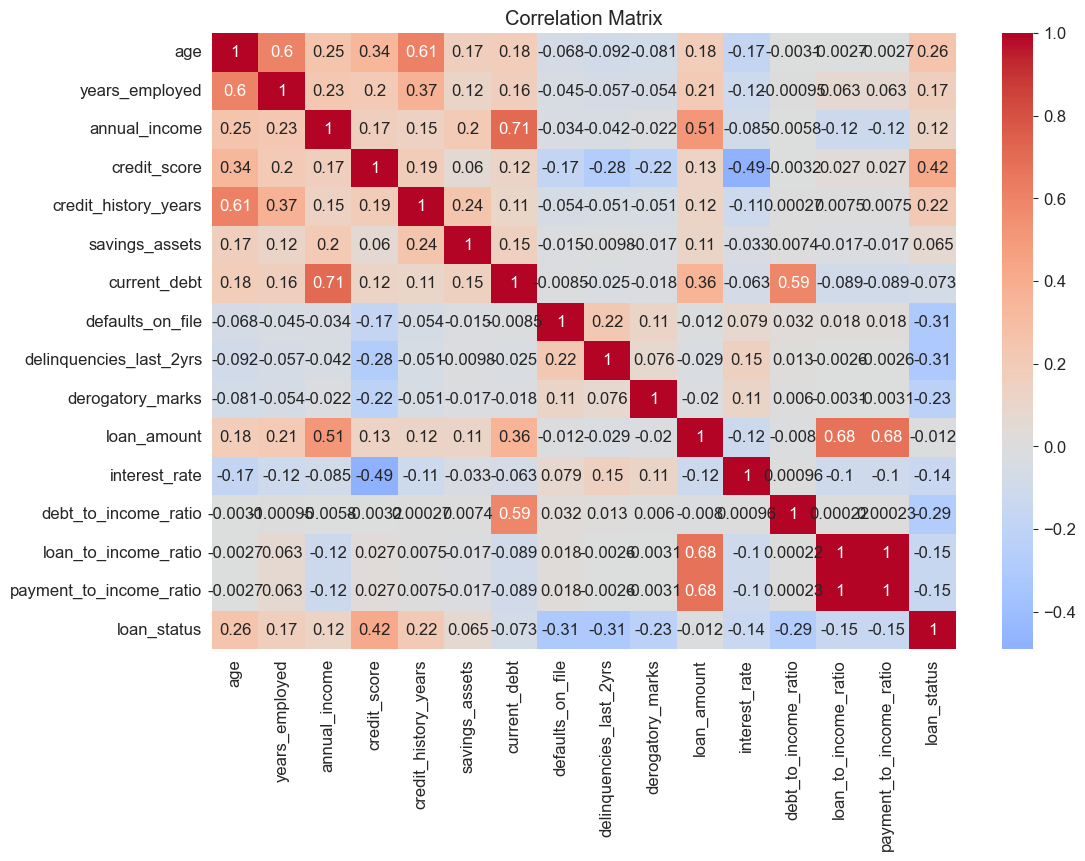


Top Correlations with Default:


loan_status                1.000000
credit_score               0.418155
age                        0.259172
credit_history_years       0.219413
years_employed             0.167925
annual_income              0.121094
savings_assets             0.064557
loan_amount               -0.011715
current_debt              -0.072894
interest_rate             -0.142017
loan_to_income_ratio      -0.151613
payment_to_income_ratio   -0.151618
derogatory_marks          -0.225930
debt_to_income_ratio      -0.285431
defaults_on_file          -0.308755
delinquencies_last_2yrs   -0.311981
Name: loan_status, dtype: float64

In [45]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('loan_status')  # Remove target variable

# Correlation matrix for numerical features
corr_matrix = df[num_cols + ['loan_status']].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Top correlations with Default
print("\nTop Correlations with Default:")
display(corr_matrix['loan_status'].sort_values(ascending=False))

### Suppression du ratio "payement_to_income_ratio"

In [46]:
df.drop('payment_to_income_ratio', axis=1, inplace=True)

## ETAPE 2 — Data preprocessing

### 2-1 Train-Test Split

In [47]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['loan_status'])
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # Maintenir la distribution des classes
)

print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")
print(f"Balance train → 1: {y_train.mean():.3f} | test → 1: {y_test.mean():.3f}")

X_train : (22020, 17) | X_test : (5506, 17)
Balance train → 1: 0.800 | test → 1: 0.800


### 2-3 Transformations logarithmiques 

#### Sélection et application du log

In [48]:
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

skewed_features = skewness[
    (abs(skewness) > 1) &
    (skewness.index.isin(numeric_cols))
].index

In [49]:
skewness = X_train[numeric_cols].skew()
skewed_features = skewness[abs(skewness) > 1].index

In [50]:
exclude_cols = [
    'defaults_on_file',
    'delinquencies_last_2yrs',
    'derogatory_marks',
    'loan_status'
]

skewed_features = [col for col in skewed_features if col not in exclude_cols]

In [51]:
import numpy as np

X_train[skewed_features] = np.log1p(X_train[skewed_features])
X_test[skewed_features] = np.log1p(X_test[skewed_features])

### Vérification du skewness

In [53]:
print(X_train[skewed_features].skew())


years_employed   -0.216540
annual_income     0.139949
savings_assets   -0.264718
current_debt     -0.471605
dtype: float64


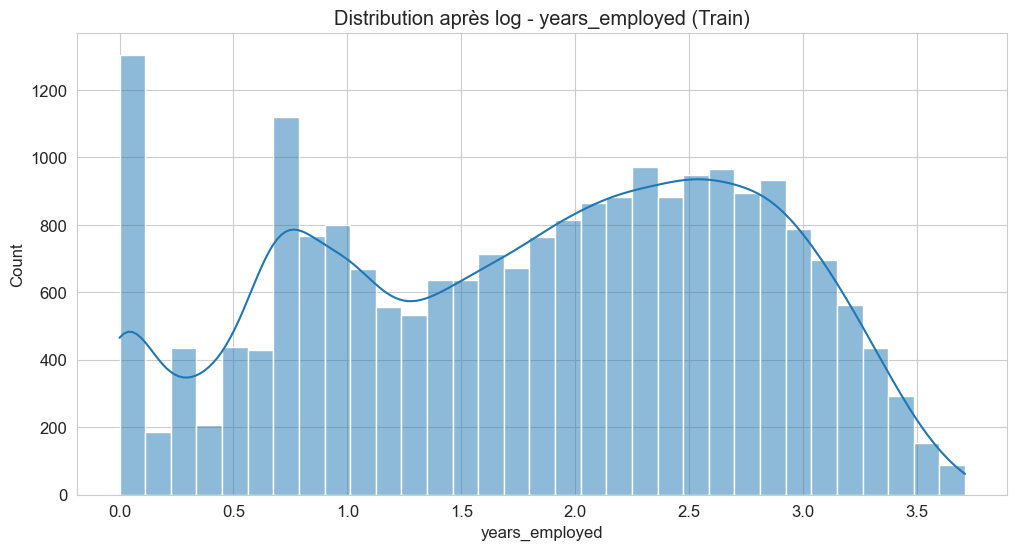

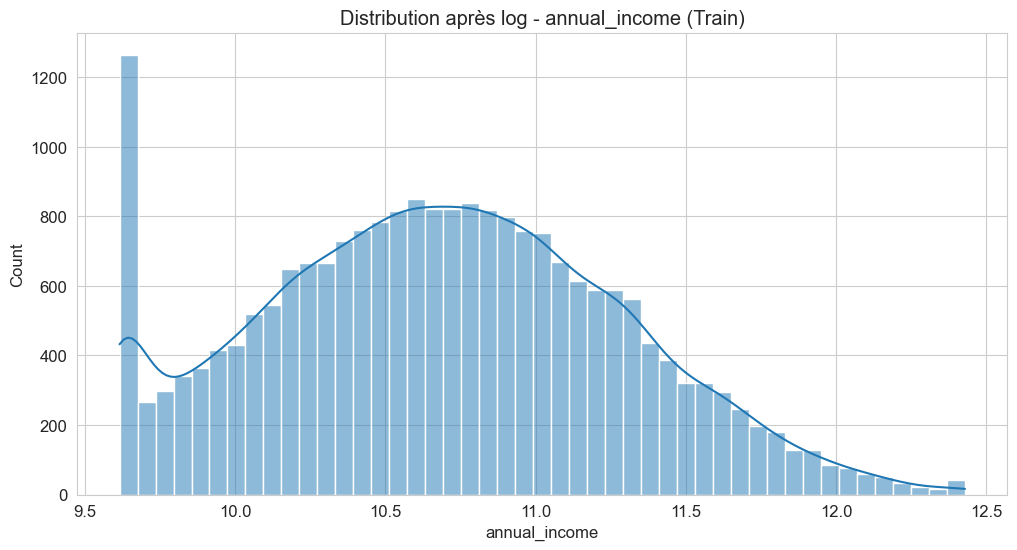

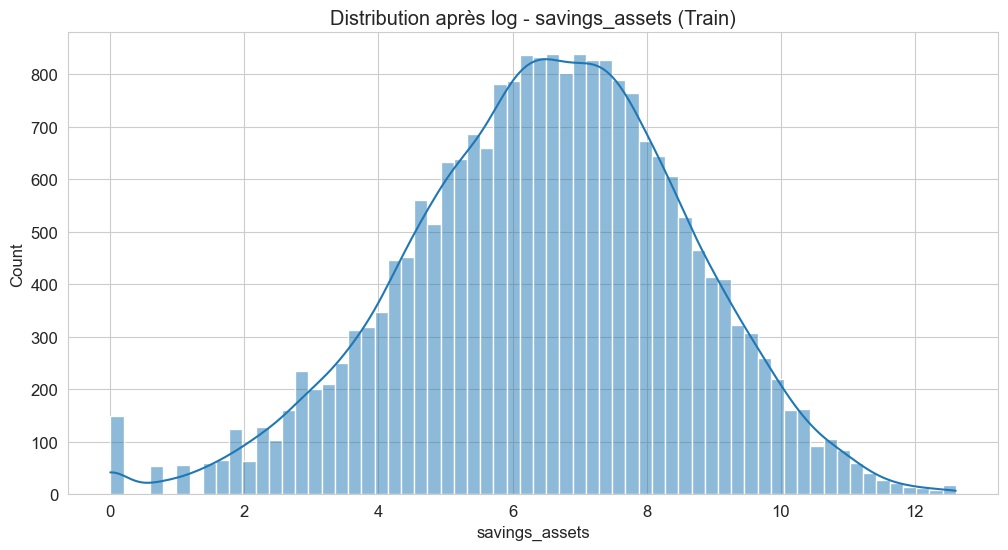

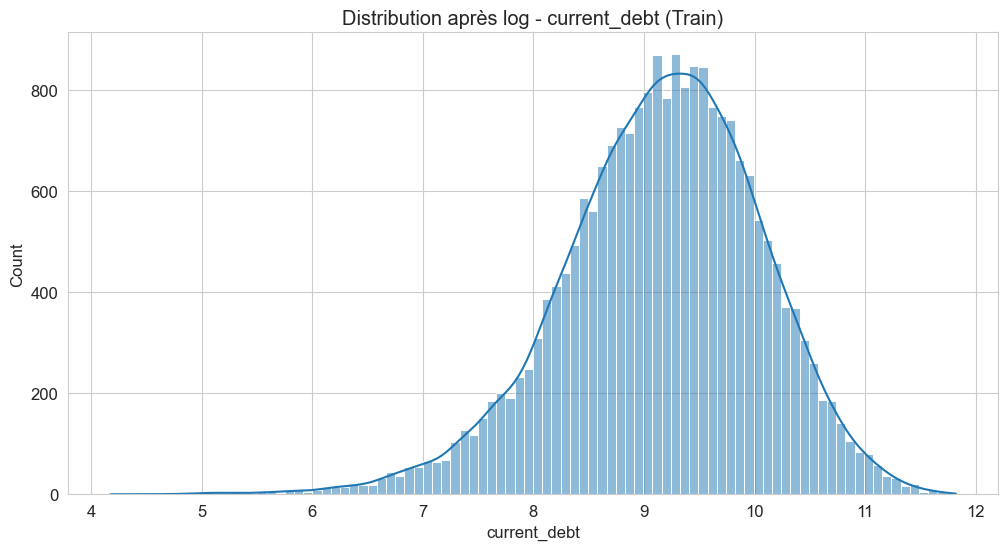

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in skewed_features:
    sns.histplot(X_train[col], kde=True)
    plt.title(f"Distribution après log - {col} (Train)")
    plt.show()

### 2-3 Categorical Encoding

In [55]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
 
categorical_cols = ['occupation_status', 'product_type', 'loan_intent']

encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# FIT uniquement sur train
X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat  = encoder.transform(X_test[categorical_cols])

# Convertir en DataFrame
encoded_cols = encoder.get_feature_names_out(categorical_cols)

X_train_cat = pd.DataFrame(X_train_cat, columns=encoded_cols, index=X_train.index)
X_test_cat  = pd.DataFrame(X_test_cat, columns=encoded_cols, index=X_test.index)

# Supprimer colonnes catégorielles originales
X_train = X_train.drop(columns=categorical_cols)
X_test  = X_test.drop(columns=categorical_cols)

# Ajouter les nouvelles colonnes
X_train = pd.concat([X_train, X_train_cat], axis=1)
X_test  = pd.concat([X_test, X_test_cat], axis=1)

### 2-4 SMOTE

In [56]:
# Imbalanced-learn
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

## ETAPE 3 — Sélection des variables

### 3-2 F-Anova (Numérique vs Cible)

In [57]:
from sklearn.feature_selection import f_classif
import pandas as pd

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

f_scores, p_values = f_classif(X_train[num_cols], y_train)

anova_results = pd.DataFrame({
    'Variable': num_cols,
    'F_score': f_scores,
    'p_value': p_values
}).sort_values(by='p_value')

print(anova_results)

                           Variable      F_score        p_value
0                               age  1633.051254   0.000000e+00
3                      credit_score  4693.801928   0.000000e+00
7                  defaults_on_file  2248.580989   0.000000e+00
8           delinquencies_last_2yrs  2291.988525   0.000000e+00
12             debt_to_income_ratio  1853.181664   0.000000e+00
9                  derogatory_marks  1170.049419  6.706251e-250
4              credit_history_years  1134.780825  1.289310e-242
1                    years_employed  1013.471231  1.780441e-217
5                    savings_assets   897.562235  2.501931e-193
13             loan_to_income_ratio   514.492190  1.303644e-112
11                    interest_rate   450.469913   5.590374e-99
2                     annual_income   404.519125   3.616596e-89
18   loan_intent_Debt Consolidation   246.441474   3.089817e-55
19            loan_intent_Education   185.468786   4.591485e-42
17       product_type_Personal Loan   17

In [58]:
selected_features = anova_results[
    anova_results['p_value'] < 0.05
]['Variable']

print(selected_features)

0                                age
3                       credit_score
7                   defaults_on_file
8            delinquencies_last_2yrs
12              debt_to_income_ratio
9                   derogatory_marks
4               credit_history_years
1                     years_employed
5                     savings_assets
13              loan_to_income_ratio
11                     interest_rate
2                      annual_income
18    loan_intent_Debt Consolidation
19             loan_intent_Education
17        product_type_Personal Loan
22              loan_intent_Personal
6                       current_debt
21               loan_intent_Medical
16       product_type_Line of Credit
20      loan_intent_Home Improvement
Name: Variable, dtype: object


In [59]:
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

### 2-3 StandardScaler

In [60]:
from sklearn.preprocessing import StandardScaler

num_to_scale = [
    'annual_income',
    'current_debt',
    'savings_assets',
    'years_employed'
]

scaler = StandardScaler()

X_train_scaled = X_train_selected.copy()
X_train_scaled[num_to_scale] = scaler.fit_transform(X_train[num_to_scale])
X_test_scaled = X_test_selected.copy()
X_test_scaled[num_to_scale] = scaler.transform(X_test[num_to_scale])

## ETAPE 4 — Modélisation avec optimisation des hyperparamètres

#### Les modèles appliqués : 

Notre dataset concerne la prédiction d’acceptation de prêt (loan_status) à partir de variables financières (revenu, score de crédit, dette, etc.).
 C’est un problème de classification binaire (0 = refus, 1 = accepté)
 On a choisit d'appliquer les modèles : **Logistic Regression , Decision Tree et Random Forest .**

#### 1. Pourquoi la **Régression Logistique ?**

- Elle est très adaptée aux problèmes de crédit (utilisée en banque) ,
- elle donne une probabilité d’acceptation du prêt et
- elle permet de comprendre l’impact de variables comme :
credit_score
debt_to_income_ratio et annual_income

#### 2. Pourquoi **l’arbre de décision ?**

Notre dataset contient :
-des relations complexes (ex: revenu + dette + historique) .
Donc , il permet de modéliser des décisions réelles de banque

#### 3. Pourquoi **Random Forest ?**

Notre dataset est :

- assez grand (50 000 lignes) et présente plusieurs variables importantes .

 Donc ce modèle est très adapté aux problèmes financiers réels

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

results={}



## 4-1 Régression logistique

### Courbe ROC

Best params: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
AUC CV: 0.9541103214322566
Train AUC: 0.9544664250335363
Test AUC: 0.9599218008500804


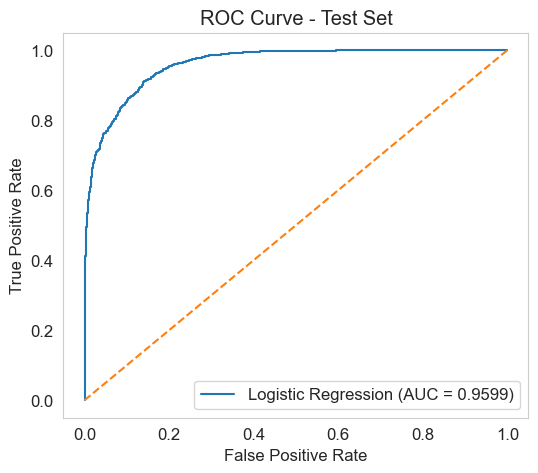

In [64]:
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, auc, f1_score, accuracy_score

# =========================
# 1. GridSearchCV :fct pour rechercher automatiquement les meilleurs hyperparametres 
# =========================
# Parametres :
#   C       = 1/lambda (regularisation)
#   penalty = l1 (Lasso : rendre certains coeff à 0) ou l2 (Ridge : coeff petits mais non nuls)
#   solver  = liblinear (l1+l2) : algorithme qui sert à entrainer le modèle
#   max_iter = iterations max pour convergence
# ============================================================

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_

# =========================
# 2. Évaluation globale
# =========================

# Probabilités
proba_train = best_lr.predict_proba(X_train_scaled)[:, 1]
proba_test = best_lr.predict_proba(X_test_scaled)[:, 1]

# AUC
train_auc = roc_auc_score(y_train, proba_train)
test_auc = roc_auc_score(y_test, proba_test)

print("Best params:", grid_lr.best_params_)
print("AUC CV:", grid_lr.best_score_)
print("Train AUC:", train_auc)
print("Test AUC:", test_auc)

# =========================
# 3. Courbe ROC (test)
# =========================

fpr, tpr, _ = roc_curve(y_test, proba_test)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_val:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.grid()
plt.show()

#### Interpretation de le courbe ROC :
**1. Forme de la courbe :**

La courbe ROC est très proche du coin supérieur gauche, ce qui indique :
- Un *taux de vrais positifs (TPR) élevé*
- Un *taux de faux positifs (FPR) faible*


**2. Comparaison avec le hasard :**

La ligne diagonale représente un modèle aléatoire (AUC = 0.5).

La courbe du modèle est largement au-dessus, donc il est *bien meilleur que le hasard*.






### Courbe Precision-Recall

**Precision (Précision) : parmi les prédictions positives, combien sont correctes**

Precision= (TP+FP)/TP
	​





**Recall (Rappel) : parmi les vrais positifs, combien ont été détectés**

Recall= (TP+FN)/TP
	​

Chaque point de la courbe correspond à un seuil de décision différent.

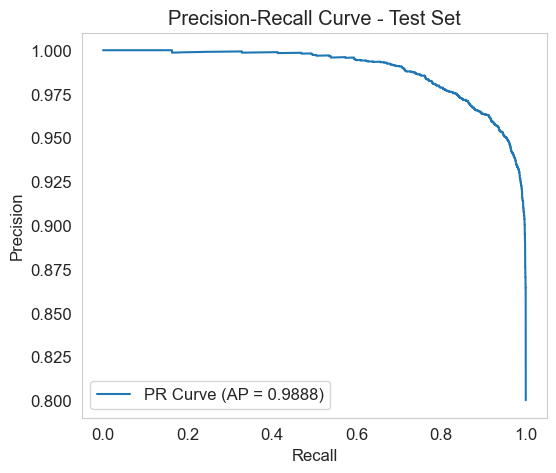

In [26]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# scores
precision, recall, thresholds = precision_recall_curve(y_test, proba_test)

# Average Precision (score global)
ap_score = average_precision_score(y_test, proba_test)

# plot
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.4f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Test Set")
plt.legend()
plt.grid()
plt.show()



Pour des recall faibles à moyens **(0 → 0.7) :**

**Precision ≈ 1.0**
**Le modèle fait presque aucune erreur (très peu de faux positifs)**

Quand le recall augmente **(0.7 → 0.9) :**

La précision diminue légèrement **(~0.97 → 0.95)**

 Compromis normal : pour détecter plus de positifs, on accepte quelques erreurs

À recall proche de **1 :**

Chute de la précision **(~0.80)**
Pour capturer tous les positifs, le modèle introduit plus de faux positifs

## 4-2 Arbre de décision

Fitting 5 folds for each of 320 candidates, totalling 1600 fits
DECISION TREE — Meilleurs hyperparamètres
Paramètres  : {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}
AUC-ROC CV  : 0.9328
Profondeur  : 7
Nb feuilles : 97

DECISION TREE — Résultats test
AUC-ROC  : 0.9372
F1-Score : 0.9159
Accuracy : 0.8714
Precision: 0.9604
Recall   : 0.8754


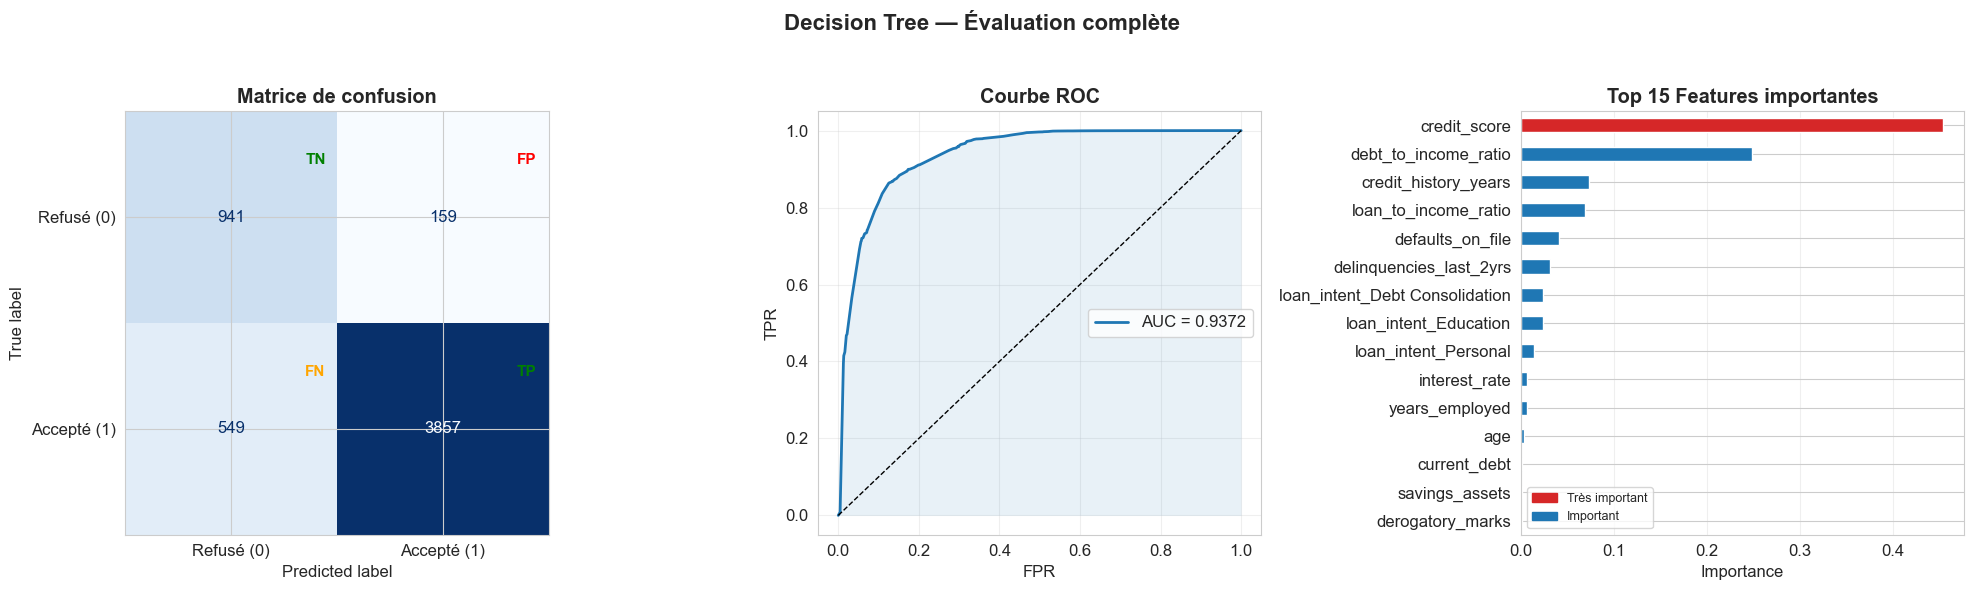

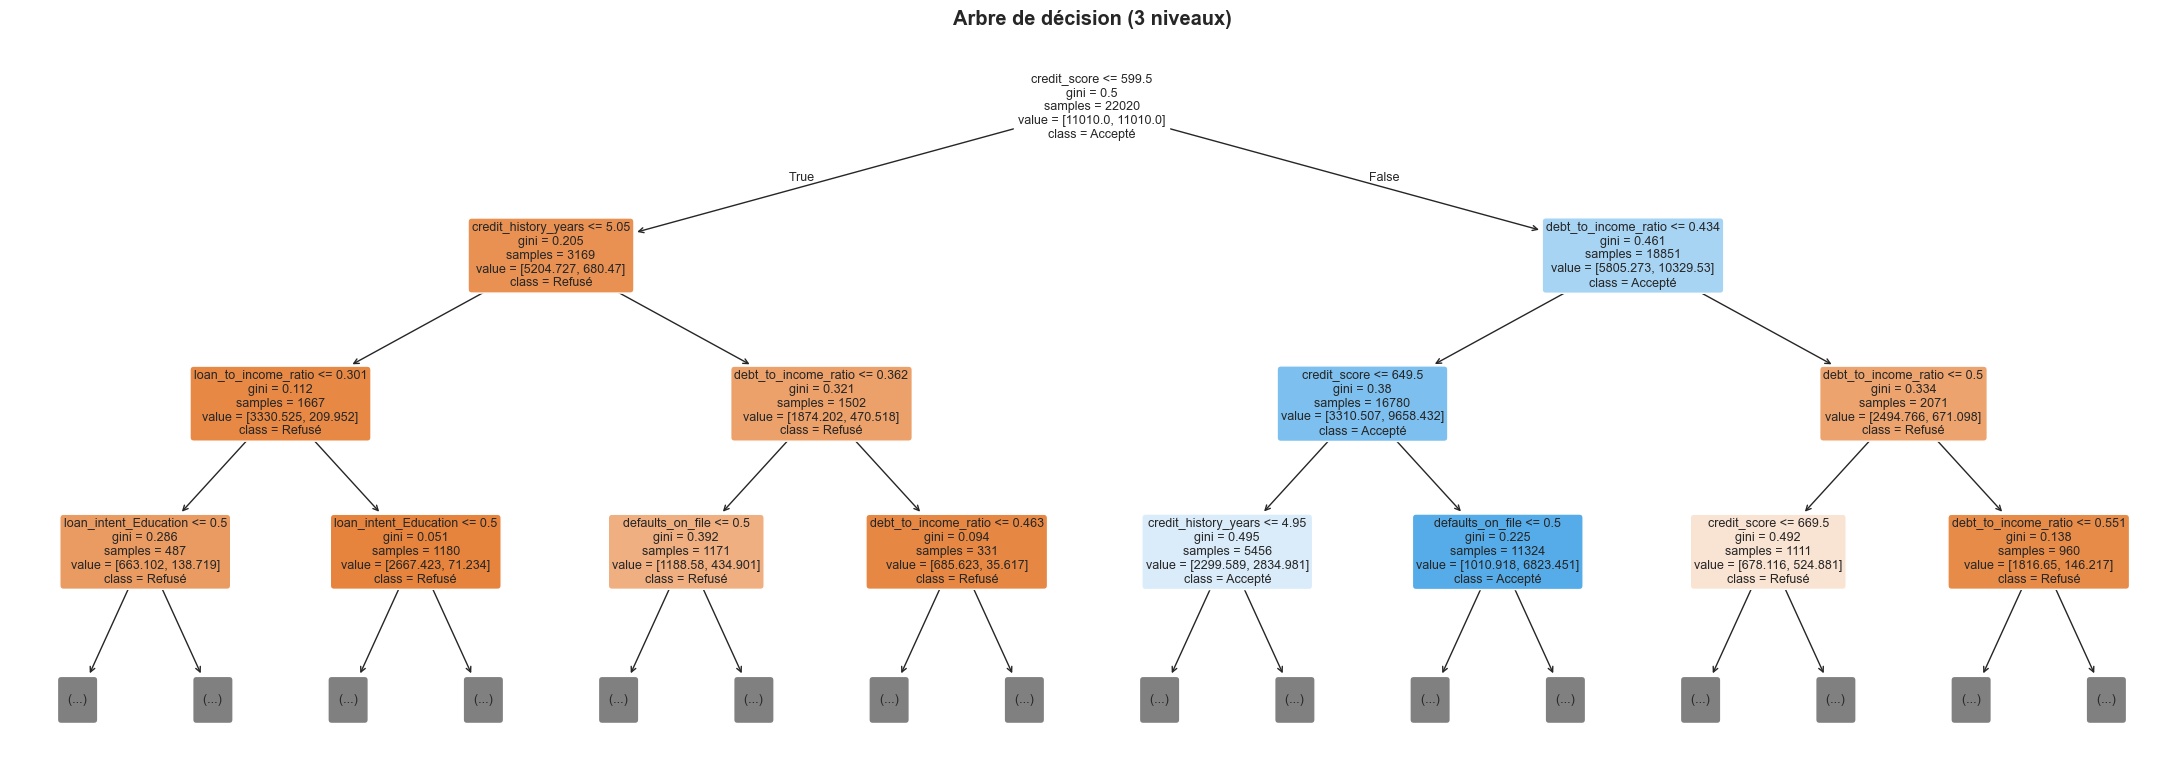


Règles de décision :
|--- credit_score <= 599.50
|   |--- credit_history_years <= 5.05
|   |   |--- loan_to_income_ratio <= 0.30
|   |   |   |--- loan_intent_Education <= 0.50
|   |   |   |   |--- current_debt <= 9.05
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- current_debt >  9.05
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- loan_intent_Education >  0.50
|   |   |   |   |--- delinquencies_last_2yrs <= 0.50
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- delinquencies_last_2yrs >  0.50
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |--- loan_to_income_ratio >  0.30
|   |   |   |--- loan_intent_Education <= 0.50
|   |   |   |   |--- loan_intent_Personal <= 0.50
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- loan_intent_Personal >  0.50
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- loan_intent_Education >  0.50
|   |   |   |   |--- delinquenci

In [65]:
# ============================================================
# DECISION TREE — Loan Prediction (VERSION CORRIGÉE)
# ============================================================

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                             precision_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, classification_report)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

models = {}
optimal_thresholds = {}

# ─────────────────────────────────────────────
# 1. OPTIMISATION DES HYPERPARAMÈTRES
# ─────────────────────────────────────────────

# ============================================================
# Parametres :
#   criterion         = gini (par defaut): proba qu'un individu appartient à une classe differenrente de l'autre 
#                       entropy : mesure la surprise
#   max_depth         = profondeur max (None = complet)
#   min_samples_split = N min pour diviser un noeud
#   min_samples_leaf  = N min dans une feuille
# ============================================================

param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_

print("=" * 50)
print("DECISION TREE — Meilleurs hyperparamètres")
print("=" * 50)
print(f"Paramètres  : {grid_dt.best_params_}")
print(f"AUC-ROC CV  : {grid_dt.best_score_:.4f}")
print(f"Profondeur  : {best_dt.get_depth()}")
print(f"Nb feuilles : {best_dt.get_n_leaves()}")

# ─────────────────────────────────────────────
# 2. ÉVALUATION
# ─────────────────────────────────────────────

proba_dt = best_dt.predict_proba(X_test)[:, 1]
preds_dt = (proba_dt >= 0.5).astype(int)

auc_test = roc_auc_score(y_test, proba_dt)

print("\n" + "=" * 50)
print("DECISION TREE — Résultats test")
print("=" * 50)
print(f"AUC-ROC  : {auc_test:.4f}")
print(f"F1-Score : {f1_score(y_test, preds_dt):.4f}")
print(f"Accuracy : {accuracy_score(y_test, preds_dt):.4f}")
print(f"Precision: {precision_score(y_test, preds_dt):.4f}")
print(f"Recall   : {recall_score(y_test, preds_dt):.4f}")



# ─────────────────────────────────────────────
# 3. VISUALISATIONS
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Decision Tree — Évaluation complète', fontsize=16, fontweight='bold')

# ─── 3a. Matrice de confusion ───
ax = axes[0]
cm = confusion_matrix(y_test, preds_dt)
disp = ConfusionMatrixDisplay(cm, display_labels=['Refusé (0)', 'Accepté (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de confusion', fontweight='bold')

labels = [['TN', 'FP'], ['FN', 'TP']]
colors = [['green', 'red'], ['orange', 'green']]

for i in range(2):
    for j in range(2):
        ax.text(j + 0.35, i - 0.25, labels[i][j],
                color=colors[i][j], fontsize=11, fontweight='bold')

# ─── 3b. ROC Curve ───
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, proba_dt)

ax.plot(fpr, tpr, lw=2, label=f'AUC = {auc_test:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.fill_between(fpr, tpr, alpha=0.1)

ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('Courbe ROC', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# ─── 3c. Feature importance ───
ax = axes[2]

feature_names = X_train.columns  # ✅ FIX IMPORTANT

importances = pd.Series(best_dt.feature_importances_, index=feature_names)
top15 = importances.nlargest(15).sort_values()

colors_bar = ['#d62728' if v >= top15.max()*0.6 else '#1f77b4'
              for v in top15.values]

top15.plot(kind='barh', ax=ax, color=colors_bar)

ax.set_title('Top 15 Features importantes', fontweight='bold')
ax.set_xlabel('Importance')

red_patch = mpatches.Patch(color='#d62728', label='Très important')
blue_patch = mpatches.Patch(color='#1f77b4', label='Important')
ax.legend(handles=[red_patch, blue_patch], fontsize=9)

ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ─────────────────────────────────────────────
# 4. VISUALISATION ARBRE
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(22, 8))

plot_tree(
    best_dt,
    max_depth=3,
    feature_names=X_train.columns,   # ✅ FIX IMPORTANT
    class_names=['Refusé', 'Accepté'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)

ax.set_title('Arbre de décision (3 niveaux)', fontweight='bold')

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 5. EXPORT RÈGLES
# ─────────────────────────────────────────────

tree_rules = export_text(best_dt, feature_names=list(X_train.columns), max_depth=4)

print("\nRègles de décision :")
print(tree_rules)

# ─────────────────────────────────────────────
# 6. SAUVEGARDE
# ─────────────────────────────────────────────

results['Decision Tree'] = {
    'best_params': grid_dt.best_params_,
    'auc_cv': grid_dt.best_score_,
    'auc_test': auc_test
}

models['Decision Tree'] = best_dt
optimal_thresholds['Decision Tree'] = 0.5

print("\n✓ Modèle ajouté aux résultats")

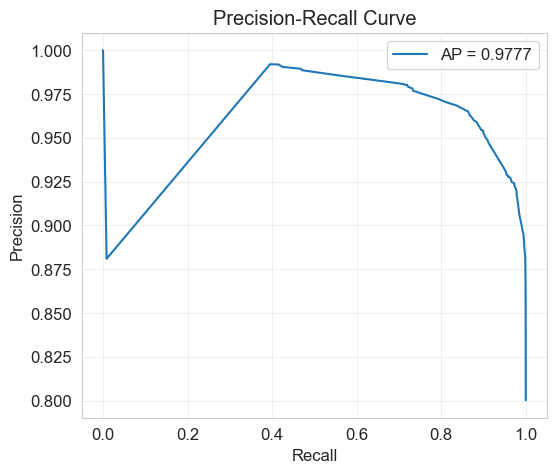

In [28]:
precision, recall, _ = precision_recall_curve(y_test, proba_dt)
ap_score = average_precision_score(y_test, proba_dt)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'AP = {ap_score:.4f}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


**Début (recall ≈ 0)**
La précision est très élevée (~1) puis chute rapidement vers ~0.88

**Montée (recall 0.05 → 0.4)**
La précision remonte jusqu’à ~0.99
cela signifie que le modèle classe mieux certains positifs après avoir relâché légèrement le seuil.

**Plateau (recall 0.4 → 0.7)**
Précision très élevée et stable (~0.98–0.99)
Le modèle est très fiable : bon équilibre entre détection des positifs et peu d’erreurs.

**Fin (recall > 0.7 → 1)**
La précision baisse progressivement puis chute (~0.80)
Pour atteindre un rappel élevé (détecter presque tous les positifs), le modèle accepte plus de faux positifs.

## 4-3  Random Forest

Random Forest Results:
{'best_params': {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}, 'auc_cv': np.float64(0.9682400229594469), 'auc_test': 0.9685012173482441}


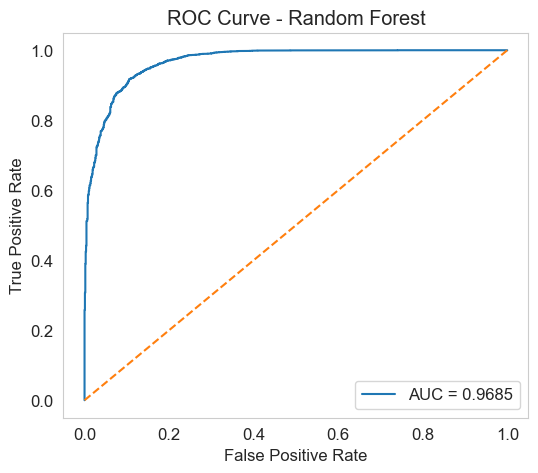

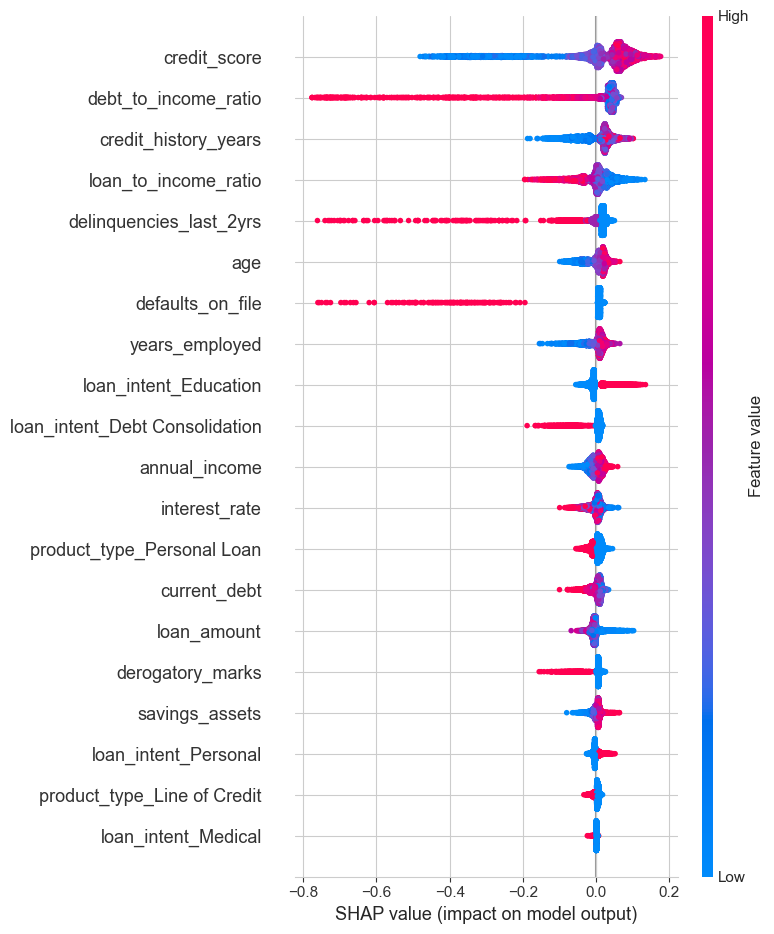

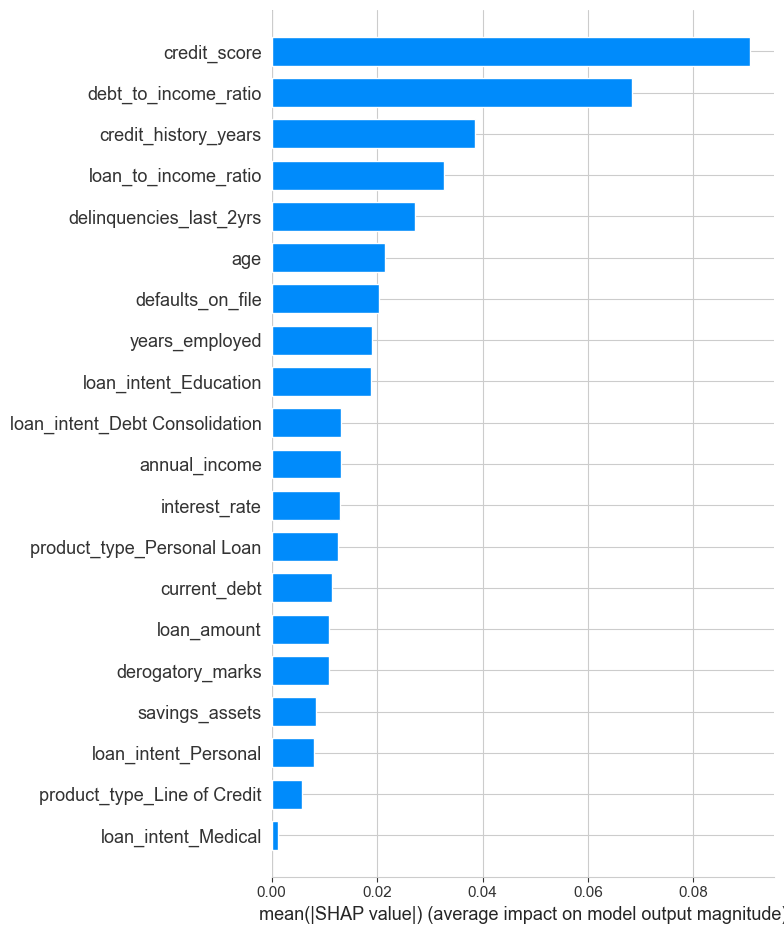

In [33]:
# ============================================================
# RANDOM FOREST + GRID SEARCH + ROC + SHAP
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve

import shap
import warnings
warnings.filterwarnings('ignore')

# =========================
# 1. GRID SEARCH
# =========================

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

# =========================
# 2. ÉVALUATION
# =========================

proba_rf = best_rf.predict_proba(X_test)[:, 1]

auc_test = roc_auc_score(y_test, proba_rf)

results['Random Forest'] = {
    'best_params': grid_rf.best_params_,
    'auc_cv': grid_rf.best_score_,
    'auc_test': auc_test
}

print("Random Forest Results:")
print(results['Random Forest'])

# =========================
# 3. ROC CURVE
# =========================

fpr, tpr, _ = roc_curve(y_test, proba_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc_test:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

# =========================
# 4. SHAP EXPLANATION
# =========================

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# --- FIX: handle both old and new SHAP output formats ---
# New SHAP versions return a 3D array (n_samples, n_features, n_classes)
# Old versions return a list of 2D arrays [class_0, class_1]

if isinstance(shap_values, list):
    # Old format: list of arrays → take class 1
    sv = shap_values[1]
    ev = explainer.expected_value[1]
else:
    # New format: 3D array → slice last dimension for class 1
    sv = shap_values[:, :, 1]
    ev = explainer.expected_value[1] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value

shap.summary_plot(sv, X_test)
shap.summary_plot(sv, X_test, plot_type="bar")

# =========================
# 6. LOCAL EXPLANATION (1 OBSERVATION)
# =========================

shap.force_plot(
    ev,
    sv[0],
    X_test.iloc[0]
)


### Interprétation de la courbe ROC  :

La courbe est très proche du coin supérieur gauche
Le modèle détecte beaucoup de vrais positifs avec peu de faux positifs
AUC = 0.9685

---

### Interprétation Shap : Quelle variable a augmenté la prédiction et laquelle qui a diminué la prédiction 

**1. Importance des variables:**

Les variables les plus influentes (en haut) sont :

credit_score
debt_to_income_ratio
credit_history_years
loan_to_income_ratio

 Ce sont elles qui impactent le plus la décision du modèle.
 
---

 **2. Sens de l’impact:**

credit_score :
Valeurs élevées (rouge) → impact positif (réduit le risque)
Valeurs faibles (bleu) → impact négatif (augmente le risque)

debt_to_income_ratio :
Valeurs élevées → impact négatif fort
 Plus le ratio est élevé, plus le risque augmente


credit_history_years :
Historique long → positif
Historique court → négatif

loan_to_income_ratio :
Valeurs élevées → augmente le risque







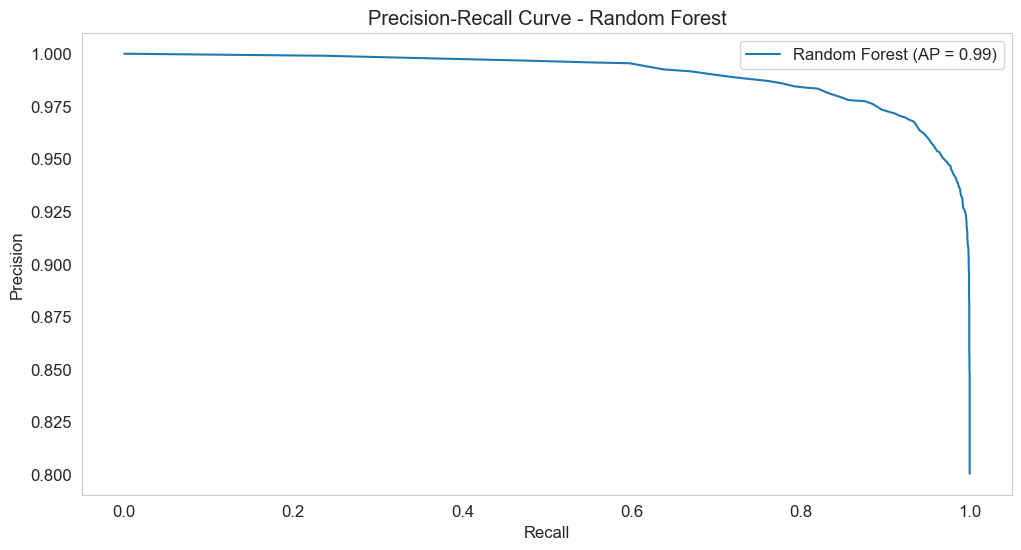

In [66]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. Entraîner le modèle Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 2. Probabilités de la classe positive
y_scores = rf.predict_proba(X_test)[:, 1]

# 3. Calcul Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# 4. Average Precision (score global PR)
ap_score = average_precision_score(y_test, y_scores)

# 5. Tracer la courbe
plt.figure()
plt.plot(recall, precision, label=f'Random Forest (AP = {ap_score:.2f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.legend()
plt.grid()
plt.show()

Cette courbe Precision-Recall montre une précision presque parfaite (~1) sur une grande partie du recall, ce qui indique que le modèle Random Forest fait très peu de faux positifs tout en détectant bien les vrais positifs.

La chute de précision à la fin (recall → 1) est normale : pour capturer tous les positifs, le modèle accepte plus d’erreurs, mais avec AP ≈ 0.99, la performance globale reste excellente.

## ETAPE 5 — Évaluation des résultats des modèles (métriques, courbes ROC)

In [67]:
models = {}
optimal_thresholds = {}
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

models['Logistic Regression'] = log_reg
optimal_thresholds['Logistic Regression'] = 0.5
models['Decision Tree'] = best_dt
optimal_thresholds['Decision Tree'] = 0.5
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

models['Random Forest'] = rf
optimal_thresholds['Random Forest'] = 0.5

In [68]:
print(models.keys())

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest'])


In [ ]:
comparison = []

for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]  
    
    t = optimal_thresholds.get(name, 0.5)
    preds = (proba >= t).astype(int)

    comparison.append({
        'Model': name,
        'AUC-ROC': roc_auc_score(y_test, proba),
        'F1-Score': f1_score(y_test, preds),
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'Threshold': t
    })
print("\nComparaison des modèles :")
comparison_df = pd.DataFrame(comparison).sort_values(by='AUC-ROC', ascending=False)
display(comparison_df)


Comparaison des modèles :


,Model,AUC-ROC,F1-Score,Accuracy,Precision,Recall,Threshold
2,Random Forest,0.970001,0.962118,0.937886,0.939637,0.985701,0.5
1,Decision Tree,0.937226,0.915934,0.871413,0.960408,0.875397,0.5
0,Logistic Regression,0.898196,0.930405,0.884308,0.896988,0.966409,0.5


Notre objectif est d’éviter les faux positifs

**→ Precision est plus importante .**

 Or, la précision est le critère principal en finance, **le Decision Tree est le meilleur choix.**

COMPARAISON DES MODÈLES — ROC CURVE


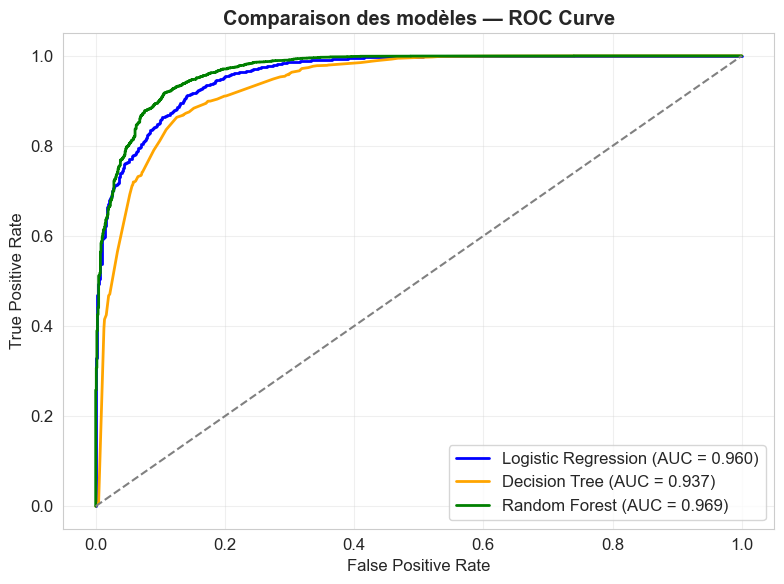

→ Figure sauvegardée : roc_comparison.png


In [74]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

print("=" * 60)
print("COMPARAISON DES MODÈLES — ROC CURVE")
print("=" * 60)

# 🔹 Probabilités des modèles
models_probs = {
    'Logistic Regression': best_lr.predict_proba(X_test_scaled)[:, 1],
    'Decision Tree': best_dt.predict_proba(X_test)[:, 1],
    'Random Forest': best_rf.predict_proba(X_test)[:, 1]
}

# 🔹 Couleurs
colors = ['blue', 'orange', 'green']

# 🔹 Un seul plot
plt.figure(figsize=(8, 6))

# 🔹 Boucle ROC
for (name, probs), color in zip(models_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {roc_auc:.3f})')

# 🔹 Ligne aléatoire
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

# 🔹 Mise en forme
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparaison des modèles — ROC Curve', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150)
plt.show()

print("→ Figure sauvegardée : roc_comparison.png")

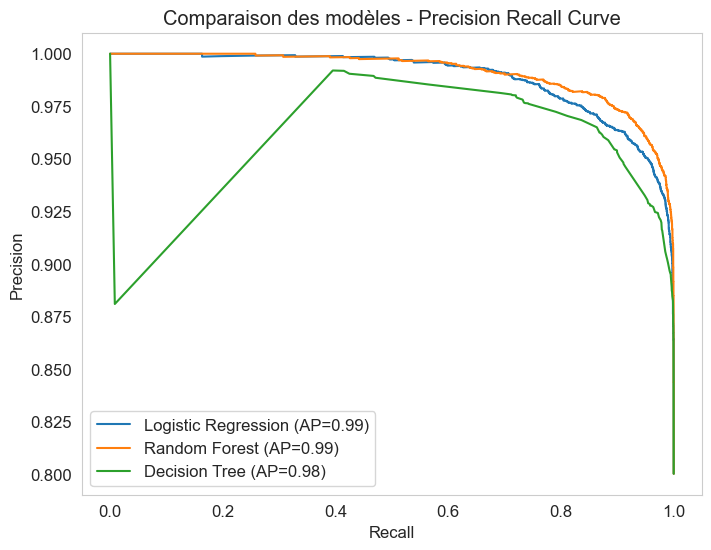

In [76]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Modèles déjà entraînés
models = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "Decision Tree": best_dt
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    
    # probabilités classe positive
    if name == "Logistic Regression":
        y_scores = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_scores = model.predict_proba(X_test)[:, 1]
    
    # precision-recall
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    
    # average precision score
    ap = average_precision_score(y_test, y_scores)
    
    # courbe
    plt.plot(recall, precision, label=f"{name} (AP={ap:.2f})")

# affichage global
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Comparaison des modèles - Precision Recall Curve")
plt.legend()
plt.grid()
plt.show()

## ETAPE 7 - Conclusion et synthèse finale

Ce projet a permis d’évaluer plusieurs modèles de classification pour **la prédiction du risque de crédit.**

 Les résultats montrent que le **Random Forest** présente les meilleures performances .

Ainsi, il constitue le modèle le plus pertinent pour ce cas d’usage.

 Cette approche offre une réelle valeur ajoutée pour les institutions financières, en améliorant la prise de décision, la gestion du risque et l’optimisation du processus d’octroi de crédit.

Projet réalisé par :

Chaima Bdiri · Yoldez Boubahri